# Practical Session 05c &mdash; Comparing the generative classifiers

**Companion to Lecture&nbsp;05.** Last of three notebooks.

| # | Notebook | Topic |
|---|----------|-------|
| 05a | Gaussian naive Bayes | fit a Gaussian per feature per class; the axis-aligned boundary |
| 05b | LDA & QDA | the full covariance: one shape per class, or one shared |
| **05c** | **comparing them** | **the three models side by side, on real data (this notebook)** |

We now have three generative classifiers for continuous features, and they differ in exactly one
thing: **how much of the covariance they are allowed to model.**

| model | covariance per class | boundary | numbers to fit ($d$ features, $K$ classes) |
|---|---|---|---|
| Gaussian naive Bayes | diagonal only | curved | $2dK$ |
| LDA | one **shared** full matrix | straight | $dK + d(d{+}1)/2$ |
| QDA | one full matrix **per class** | curved | $dK + K\,d(d{+}1)/2$ |

> &#11088; **Key idea.** More covariance freedom means a more flexible boundary but more numbers to
> estimate. The right choice depends on how much data you have and whether the classes really do have
> different shapes.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from nb_utils import use_style
from nb_data import make_gaussian_classes

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                           QuadraticDiscriminantAnalysis)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

use_style("notes")
C0, C1 = "#0072B2", "#D55E00"
print("ready")

ready


## 1. The same data, three boundaries

Two classes with genuinely **tilted and different** covariances &mdash; the case that separates the
three models most clearly.

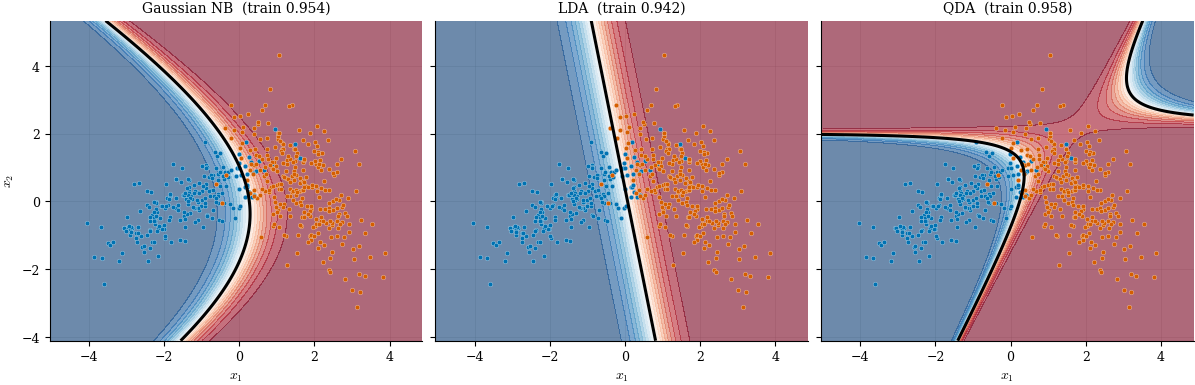

NB: upright ellipses, curved cut. LDA: one shared shape, straight cut.
QDA: two different tilted shapes, curved cut that hugs the data.


In [3]:
covs_true = np.stack([np.array([[1.3, 0.7], [0.7, 0.7]]),
                      np.array([[0.7, -0.55], [-0.55, 1.4]])])
X, y, _ = make_gaussian_classes(n=500, seed=0, mus=((-1.4, 0.0), (1.6, 0.4)), covs=covs_true)

models = {"Gaussian NB": GaussianNB(),
          "LDA": LinearDiscriminantAnalysis(),
          "QDA": QuadraticDiscriminantAnalysis()}

gx, gy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 300),
                     np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 300))
G = np.column_stack([gx.ravel(), gy.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.9), sharex=True, sharey=True)
for ax, (name, m) in zip(axes, models.items()):
    m.fit(X, y)
    Z = m.predict_proba(G)[:, 1].reshape(gx.shape)
    ax.contourf(gx, gy, Z, levels=20, cmap="RdBu_r", alpha=0.6)
    ax.contour(gx, gy, Z, levels=[0.5], colors="black", linewidths=2.2)
    for k, c in ((0, C0), (1, C1)):
        ax.scatter(X[y == k, 0], X[y == k, 1], s=11, color=c, edgecolor="white", linewidth=0.2)
    ax.set_title(f"{name}  (train {m.score(X, y):.3f})", fontsize=10); ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
plt.show()
print("NB: upright ellipses, curved cut. LDA: one shared shape, straight cut.")
print("QDA: two different tilted shapes, curved cut that hugs the data.")

## 2. How much data does each one need?

Flexibility is not free. Let us measure the test error of all three against the size of the training
set, on the same data.

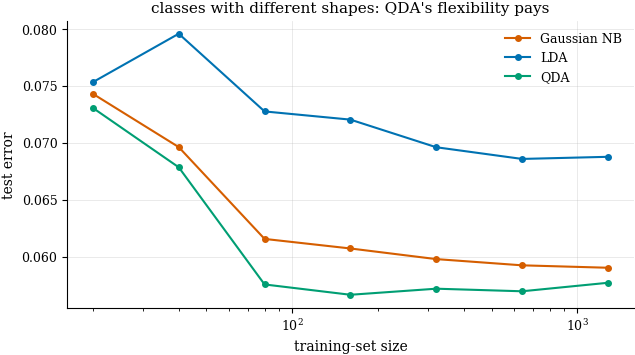

     n   Gaussian NB           LDA           QDA
    20         0.074         0.075         0.073
    40         0.070         0.080         0.068
    80         0.062         0.073         0.058
   160         0.061         0.072         0.057
   320         0.060         0.070         0.057
   640         0.059         0.069         0.057
  1280         0.059         0.069         0.058


In [4]:
Xb, yb, _ = make_gaussian_classes(n=6000, seed=11, mus=((-1.4, 0.0), (1.6, 0.4)), covs=covs_true)
Xpool, ypool, Xte, yte = Xb[:3000], yb[:3000], Xb[3000:], yb[3000:]

sizes = [20, 40, 80, 160, 320, 640, 1280]
curves = {name: [] for name in models}
for n in sizes:
    acc = {name: [] for name in models}
    for r in range(25):
        idx = np.random.default_rng(1000 * n + r).choice(3000, n, replace=False)
        if len(np.unique(ypool[idx])) < 2:
            continue
        for name, m in models.items():
            mm = m.__class__(**m.get_params()).fit(Xpool[idx], ypool[idx])
            acc[name].append(1 - mm.score(Xte, yte))
    for name in models:
        curves[name].append(np.mean(acc[name]))

fig, ax = plt.subplots(figsize=(6.4, 3.6))
for (name, e), c in zip(curves.items(), [C1, C0, "#009E73"]):
    ax.semilogx(sizes, e, "-o", ms=4, color=c, label=name)
ax.set_xlabel("training-set size"); ax.set_ylabel("test error"); ax.legend(fontsize=9)
ax.set_title("classes with different shapes: QDA's flexibility pays")
plt.show()

print(f"{'n':>6s}" + "".join(f"{name:>14s}" for name in models))
for i, n in enumerate(sizes):
    print(f"{n:6d}" + "".join(f"{curves[name][i]:14.3f}" for name in models))

> &#128161; **Intuition.** Here the two classes genuinely *do* have different shapes, so QDA's extra
> covariance earns its keep at every size, while LDA &mdash; forced to average the two shapes into one
> &mdash; never catches up. Flexibility pays **when it matches the truth**.

## 3. The other regime: when the classes *do* share a shape

Flip the experiment &mdash; give both classes the same covariance. Now LDA's assumption is exactly
right and QDA is estimating a second covariance it does not need.

In [5]:
shared_cov = np.array([[1.1, 0.45], [0.45, 0.9]])
Xs, ys, _ = make_gaussian_classes(n=6000, seed=12, mus=((-1.3, 0.0), (1.5, 0.4)), covs=shared_cov)
Xp2, yp2, Xt2, yt2 = Xs[:3000], ys[:3000], Xs[3000:], ys[3000:]

rows = []
for n in [20, 40, 80, 160, 320, 640, 1280]:
    r_ = {"n": n}
    for name, m in models.items():
        e = []
        for rep in range(25):
            idx = np.random.default_rng(7000 + 100 * n + rep).choice(3000, n, replace=False)
            if len(np.unique(yp2[idx])) < 2:
                continue
            mm = m.__class__(**m.get_params()).fit(Xp2[idx], yp2[idx])
            e.append(1 - mm.score(Xt2, yt2))
        r_[name] = np.mean(e)
    rows.append(r_)

print(f"{'n':>6s}" + "".join(f"{name:>14s}" for name in models) + "     best")
for r_ in rows:
    best = min(models, key=lambda nm: r_[nm])
    print(f"{r_['n']:6d}" + "".join(f"{r_[nm]:14.3f}" for nm in models) + f"     {best}")

     n   Gaussian NB           LDA           QDA     best
    20         0.124         0.105         0.125     LDA
    40         0.104         0.088         0.094     LDA
    80         0.102         0.084         0.085     LDA
   160         0.101         0.081         0.081     LDA
   320         0.100         0.081         0.081     LDA
   640         0.101         0.081         0.081     LDA
  1280         0.101         0.080         0.081     LDA


> &#9888;&#65039; **Watch out.** Flip the truth and the ranking flips with it: when the classes really
> share a shape, LDA wins at **every** size, and QDA &mdash; estimating a second covariance it does not
> need &mdash; is the worst of the three at small $n$ before catching up. There is no universally best
> member of this family; the winner is whichever assumption matches the data, which is exactly why you
> cross-validate.

## 4. Real data

Two bundled datasets, five-fold cross-validation. Logistic regression is included only as a familiar
**discriminative** reference point.

In [6]:
from sklearn.datasets import load_wine, load_breast_cancer
from sklearn.model_selection import cross_val_score

def bench(X, y, title):
    zoo = {"Gaussian NB": GaussianNB(),
           "LDA": LinearDiscriminantAnalysis(),
           "QDA (reg=0.1)": QuadraticDiscriminantAnalysis(reg_param=0.1),
           "logistic (ref.)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))}
    print(f"\n{title}   ({X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes)")
    print(f"   {'model':17s} {'CV accuracy':>12s}")
    for name, m in zoo.items():
        print(f"   {name:17s} {cross_val_score(m, X, y, cv=5).mean():12.3f}")

wine, cancer = load_wine(), load_breast_cancer()
bench(wine.data, wine.target, "WINE")
bench(cancer.data, cancer.target, "BREAST CANCER")


WINE   (178 samples, 13 features, 3 classes)
   model              CV accuracy
   Gaussian NB              0.966
   LDA                      0.972
   QDA (reg=0.1)            0.972
   logistic (ref.)          0.983

BREAST CANCER   (569 samples, 30 features, 2 classes)
   model              CV accuracy
   Gaussian NB              0.939
   LDA                      0.960
   QDA (reg=0.1)            0.953
   logistic (ref.)          0.981


In [7]:
# why QDA needed reg_param above: 30 features means 465 covariance numbers PER CLASS
d = cancer.data.shape[1]
print(f"breast cancer: d = {d} -> d(d+1)/2 = {d*(d+1)//2} covariance numbers per class")
print(f"class sizes: {np.bincount(cancer.target)}  <- fewer samples than parameters\n")

try:
    QuadraticDiscriminantAnalysis(reg_param=0.0).fit(cancer.data, cancer.target)
    print("unregularized QDA fitted (possibly with a collinearity warning)")
except Exception as e:
    print(f"unregularized QDA FAILED: {type(e).__name__}")
    print(f"   {str(e)[:95]}")
print("\n-> reg_param shrinks each covariance toward a sphere, making it invertible again.")

breast cancer: d = 30 -> d(d+1)/2 = 465 covariance numbers per class
class sizes: [212 357]  <- fewer samples than parameters

unregularized QDA FAILED: LinAlgError
   The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce 

-> reg_param shrinks each covariance toward a sphere, making it invertible again.


> &#9888;&#65039; **Watch out.** QDA needs enough samples **per class** to estimate a full covariance.
> With 30 features that is 465 numbers per class &mdash; more than the 212 malignant samples available.
> Either regularize (`reg_param`), reduce the dimension first, or fall back to LDA or naive Bayes.

## 5. Choosing between them

A short, practical rule:

* **Gaussian naive Bayes** &mdash; many features, few samples, or features that are roughly independent.
  Cheapest to fit and very hard to break. Its probabilities are over-confident when features are
  correlated, so trust the label more than the number.
* **LDA** &mdash; the sensible default for continuous features. One shared covariance is usually a good
  compromise, and it yields the same linear form as logistic regression.
* **QDA** &mdash; only when the classes visibly have **different shapes** *and* you have enough samples
  per class; otherwise regularize it.

All three fit in closed form with no tuning, so the honest answer is: try them and cross-validate.

In [8]:
# a compact head-to-head on wine, with the parameter counts that explain the ranking
d, K = wine.data.shape[1], len(np.unique(wine.target))
counts = {"Gaussian NB": 2 * d * K,
          "LDA": d * K + d * (d + 1) // 2,
          "QDA (reg=0.1)": d * K + K * d * (d + 1) // 2}

print(f"{'model':17s} {'CV accuracy':>12s} {'numbers fitted':>16s}")
for name, m in {"Gaussian NB": GaussianNB(),
                "LDA": LinearDiscriminantAnalysis(),
                "QDA (reg=0.1)": QuadraticDiscriminantAnalysis(reg_param=0.1)}.items():
    acc = cross_val_score(m, wine.data, wine.target, cv=5).mean()
    print(f"{name:17s} {acc:12.3f} {counts[name]:16d}")
print(f"\n(wine has only {wine.data.shape[0]} samples in total)")

model              CV accuracy   numbers fitted
Gaussian NB              0.966               78
LDA                      0.972              130
QDA (reg=0.1)            0.972              312

(wine has only 178 samples in total)


## Recap & exercises

**Recap.**
* The three models differ in **one** thing: how much covariance structure they may use &mdash; diagonal
  (naive Bayes), one shared full matrix (LDA), or one full matrix per class (QDA).
* That single choice sets both the **boundary shape** (curved / straight / curved) and the **number of
  parameters** to estimate.
* With little data the simpler model often wins even when its assumption is wrong; with enough data the
  model that matches the truth pulls ahead.
* On real data all three are competitive and need **no tuning** &mdash; they fit in closed form.
* QDA is the one that breaks: a full covariance per class needs $d(d{+}1)/2$ numbers, which on the
  breast-cancer data exceeds the samples available, so it must be regularized.

**Exercises.**
1. Repeat Section&nbsp;1 with three classes. Do the boundaries stay linear for LDA?
2. In Section&nbsp;4, run QDA on wine after reducing to 5 features with PCA. Does it beat LDA now?
3. Add 20 pure-noise features to the wine data and re-benchmark. Which model degrades most gracefully?
4. Sweep `reg_param` from 0 to 1 for QDA on breast cancer and plot CV accuracy. Where is the best value,
   and what does $\lambda=1$ correspond to?
5. Compare LDA's `coef_` with logistic regression's on wine. Are the directions similar, and does that
   match what 05b derived?

*That completes the Session&nbsp;05 arc:* Gaussian naive Bayes (05a), LDA and QDA (05b), and how to
choose between them (05c) &mdash; all from scratch and checked against scikit-learn.